# Cell 1: Load and prepare data

In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv('../data/B3DB_classification.tsv', sep='\t')

# Drop rows with invalid SMILES (defensive)
def is_valid_smiles(smi):
    mol = Chem.MolFromSmiles(smi)
    return mol is not None

df = df[df['SMILES'].apply(is_valid_smiles)].reset_index(drop=True)

# Binary label: BBB+ -> 1, BBB- -> 0
df['label'] = (df['BBB+/BBB-'] == 'BBB+').astype(int)

print(f"Final dataset size: {len(df)}")
print(f"Label distribution:\n{df['label'].value_counts()}")
df[['SMILES', 'BBB+/BBB-', 'label']].head()

Final dataset size: 7805
Label distribution:
label
1    4956
0    2849
Name: count, dtype: int64


[12:40:32] Explicit valence for atom # 10 C, 4, is greater than permitted
[12:40:32] Explicit valence for atom # 10 C, 4, is greater than permitted


,SMILES,BBB+/BBB-,label
0,O=C(O)c1cc(N=Nc2ccc(S(=O)(=O)Nc3ccccn3)cc2)ccc1O,BBB-,0
1,COC1(NC(=O)C(C(=O)O)c2ccc(O)cc2)C(=O)N2C(C(=O)...,BBB-,0
2,Oc1c(I)cc(Cl)c2cccnc12,BBB-,0
3,CCNC(=NCCSCc1ncccc1Br)NC#N,BBB-,0
4,CN1CC[C@]23c4c5ccc(OC6O[C@H](C(=O)O)[C@@H](O)[...,BBB-,0


# Cell 2 — Morgan Fingerprint Featurization

In [2]:
from rdkit.Chem import AllChem
import numpy as np

def smiles_to_morgan(smiles, n_bits=2048, radius=2):
    """Convert a SMILES string to a Morgan fingerprint bit vector."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    return np.array(fp)

# Compute fingerprints for all molecules
print("Computing Morgan fingerprints...")
fingerprints = df['SMILES'].apply(smiles_to_morgan)

# Stack into a feature matrix
X = np.vstack(fingerprints.values)
y = df['label'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Example fingerprint (first 50 bits): {X[0][:50]}")

Computing Morgan fingerprints...


[12:45:34] DEPRECATION WARNING: please use MorganGenerator
[12:45:34] DEPRECATION WARNING: please use MorganGenerator
[12:45:34] DEPRECATION WARNING: please use MorganGenerator
[12:45:34] DEPRECATION WARNING: please use MorganGenerator
[12:45:34] DEPRECATION WARNING: please use MorganGenerator
[12:45:34] DEPRECATION WARNING: please use MorganGenerator
[12:45:34] DEPRECATION WARNING: please use MorganGenerator
[12:45:34] DEPRECATION WARNING: please use MorganGenerator
[12:45:34] DEPRECATION WARNING: please use MorganGenerator
[12:45:34] DEPRECATION WARNING: please use MorganGenerator
[12:45:34] DEPRECATION WARNING: please use MorganGenerator
[12:45:34] DEPRECATION WARNING: please use MorganGenerator
[12:45:34] DEPRECATION WARNING: please use MorganGenerator
[12:45:34] DEPRECATION WARNING: please use MorganGenerator
[12:45:34] DEPRECATION WARNING: please use MorganGenerator
[12:45:34] DEPRECATION WARNING: please use MorganGenerator
[12:45:34] DEPRECATION WARNING: please use MorganGenerat

Feature matrix shape: (7805, 2048)
Labels shape: (7805,)
Example fingerprint (first 50 bits): [0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]


[12:45:42] DEPRECATION WARNING: please use MorganGenerator
[12:45:42] DEPRECATION WARNING: please use MorganGenerator
[12:45:42] DEPRECATION WARNING: please use MorganGenerator
[12:45:42] DEPRECATION WARNING: please use MorganGenerator
[12:45:42] DEPRECATION WARNING: please use MorganGenerator
[12:45:42] DEPRECATION WARNING: please use MorganGenerator
[12:45:42] DEPRECATION WARNING: please use MorganGenerator
[12:45:42] DEPRECATION WARNING: please use MorganGenerator
[12:45:42] DEPRECATION WARNING: please use MorganGenerator
[12:45:42] DEPRECATION WARNING: please use MorganGenerator
[12:45:42] DEPRECATION WARNING: please use MorganGenerator
[12:45:42] DEPRECATION WARNING: please use MorganGenerator
[12:45:42] DEPRECATION WARNING: please use MorganGenerator
[12:45:42] DEPRECATION WARNING: please use MorganGenerator
[12:45:42] DEPRECATION WARNING: please use MorganGenerator
[12:45:42] DEPRECATION WARNING: please use MorganGenerator
[12:45:42] DEPRECATION WARNING: please use MorganGenerat

In [3]:
from rdkit.Chem import rdFingerprintGenerator

# New recommended API: build a reusable generator
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_morgan_v2(smiles):
    """Convert SMILES to Morgan fingerprint using the new MorganGenerator API."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = morgan_gen.GetFingerprint(mol)
    return np.array(fp)

# Recompute fingerprints with the new API
print("Recomputing Morgan fingerprints (new API)...")
fingerprints = df['SMILES'].apply(smiles_to_morgan_v2)
X = np.vstack(fingerprints.values)
y = df['label'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Bits set in first molecule: {X[0].sum()} / 2048")

Recomputing Morgan fingerprints (new API)...
Feature matrix shape: (7805, 2048)
Labels shape: (7805,)
Bits set in first molecule: 45 / 2048


# Cell 3: Train/test split + Random Forest baseline

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Split into train/test (stratified to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Train class ratio: {y_train.mean():.3f}, Test class ratio: {y_test.mean():.3f}")

# Train Random Forest baseline
print("\nTraining Random Forest...")
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Predict on test set
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

# Evaluate
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba):.4f}")
print(f"\nClassification report:\n{classification_report(y_test, y_pred, target_names=['BBB-', 'BBB+'])}")

Train set: (6244, 2048), Test set: (1561, 2048)
Train class ratio: 0.635, Test class ratio: 0.635

Training Random Forest...

Accuracy: 0.8834
ROC-AUC:  0.9612

Classification report:
              precision    recall  f1-score   support

        BBB-       0.89      0.78      0.83       570
        BBB+       0.88      0.94      0.91       991

    accuracy                           0.88      1561
   macro avg       0.89      0.86      0.87      1561
weighted avg       0.88      0.88      0.88      1561



# Cell 4: Plot ROC Curve

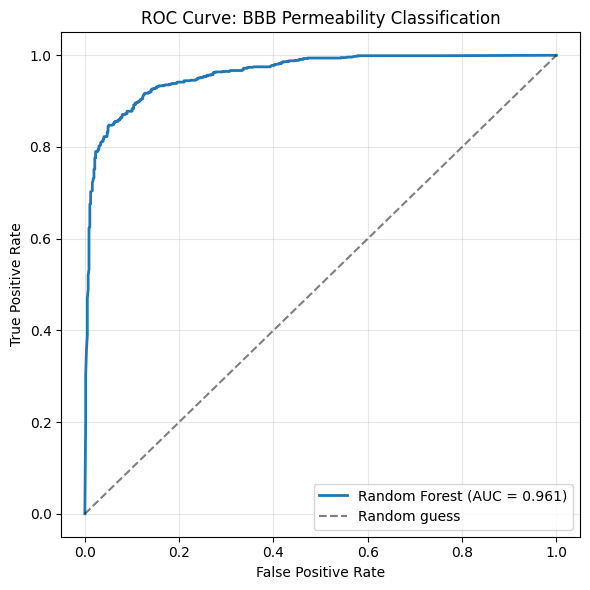

ROC curve saved to ../results/roc_curve.png


In [5]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random guess', alpha=0.5)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: BBB Permeability Classification')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../results/roc_curve.png', dpi=150)
plt.show()

print("ROC curve saved to ../results/roc_curve.png")

In [6]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


# Cell 5: Plot Confusion Matrix

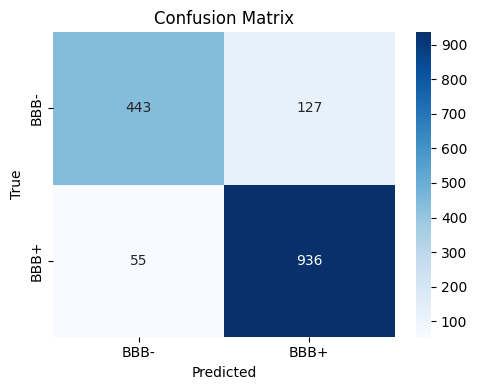

In [7]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['BBB-', 'BBB+'],
            yticklabels=['BBB-', 'BBB+'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('../results/confusion_matrix.png', dpi=150)
plt.show()

# Cell 6: Save model and perform error analysis

In [8]:
import joblib
from sklearn.model_selection import train_test_split

# Save the trained model
joblib.dump(rf, '../results/rf_baseline_model.pkl')
print("Model saved to ../results/rf_baseline_model.pkl")

# Reconstruct test indices to inspect errors
train_idx, test_idx = train_test_split(
    np.arange(len(df)), test_size=0.2, random_state=42, stratify=y
)
df_test = df.iloc[test_idx].copy()
df_test['predicted'] = y_pred
df_test['pred_proba'] = y_proba
df_test['correct'] = (df_test['label'] == df_test['predicted'])

# Most confident wrong predictions: model was sure, but wrong
wrong = df_test[~df_test['correct']].copy()
wrong['confidence'] = np.where(
    wrong['predicted'] == 1,
    wrong['pred_proba'],
    1 - wrong['pred_proba']
)
wrong_sorted = wrong.sort_values('confidence', ascending=False)

print(f"\nTotal errors: {len(wrong)} out of {len(df_test)}")
print("\nTop 5 most confident wrong predictions:")
print(wrong_sorted[['compound_name', 'SMILES', 'BBB+/BBB-', 'predicted', 'pred_proba']].head())

Model saved to ../results/rf_baseline_model.pkl

Total errors: 182 out of 1561

Top 5 most confident wrong predictions:
     compound_name                                             SMILES  \
3573           NaN  C[C@H]1C[C@H]2[C@@H]3CCC4=CC(=O)C=CC4(C)C3(F)[...   
7197           NaN  CC[C@@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)...   
3729   dextramycin  O=C(N[C@@H](CO)[C@@H](O)c1ccc([N+](=O)[O-])cc1...   
5507    plicamycin  CO[C@H](C(=O)[C@@H](O)[C@@H](C)O)[C@@H]1Cc2cc3...   
6824           NaN  C#C[C@@]1(O)CC[C@@H]2[C@@H]3CCC4=CC(=O)CC[C@@H...   

     BBB+/BBB-  predicted  pred_proba  
3573      BBB-          1     1.00000  
7197      BBB+          0     0.00000  
3729      BBB-          1     0.99000  
5507      BBB-          1     0.98500  
6824      BBB+          0     0.02013  
